In [3]:
!pip install openpyxl
import pandas as pd
import numpy as np
def run_query(query):
    return pd.read_sql(query, engine)


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df = pd.read_excel('Superstore.xlsx')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [7]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True, errors="coerce")

In [9]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')
print("\nColumn names standardized.")
print(df.columns)


Column names standardized.
Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='str')


In [11]:
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_weekday'] = df['order_date'].dt.day_name()
df['shipping_time_days'] = (df['ship_date'] - df['order_date']).dt.days
print("\nNew features created: 'order_year', 'order_month', 'order_weekday', 'shipping_time_days'")
display(df.head())


New features created: 'order_year', 'order_month', 'order_weekday', 'shipping_time_days'


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,order_year,order_month,order_weekday,shipping_time_days
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,8,Thursday,92
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,8,Thursday,92
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,12,Tuesday,-173
3,4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,11,Tuesday,-23
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,11,Tuesday,-23


In [12]:
ds = pd.read_excel('sales_forecast.xlsx')
dt = pd.read_excel('cleaned_superstore_dataset.xlsx')
du = pd.read_csv('segmented_customers.csv')

In [13]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
url = URL.create(
    "postgresql+psycopg2",
    username="postgres",
    password="navi@2006",
    host="localhost",
    port=5432,
    database="store_database"
)
engine = create_engine(url)
df.to_sql("df", engine, if_exists="replace", index=False)
ds.to_sql("ds", engine, if_exists="replace", index=False)
du.to_sql("du", engine, if_exists="replace", index=False)
dt.to_sql("dt", engine, if_exists="replace", index=False)
print("All 4 tables uploaded successfully!")

All 4 tables uploaded successfully!


In [16]:
query = """
WITH customer_metrics AS (
SELECT customer_id, COUNT(DISTINCT order_id) AS total_orders, SUM(sales) AS total_revenue, SUM(profit) AS total_profit,AVG(sales) AS avg_order_value
FROM dt
GROUP BY customer_id
)
SELECT c.customer_id,c.total_orders,c.total_revenue,c.total_profit,c.avg_order_value,d.recency,d.frequency,d.monetary,d.cluster,
(c.total_revenue) AS clv FROM customer_metrics c
JOIN du d ON c.customer_id = d.customer_id
ORDER BY clv DESC;
"""

clv_df = pd.read_sql(query, engine)

In [17]:
segment_summary = clv_df.groupby("cluster").agg({
"clv": "mean","total_orders": "mean","monetary": "mean"
}).sort_values(by="clv", ascending=False)

print(segment_summary)

                 clv  total_orders     monetary
cluster                                        
1        9208.291266      8.242857  9208.291266
3        3237.664040      8.527211  3237.664040
0        1680.496499      4.714715  1680.496499
2        1470.228226      3.697917  1470.228226


In [19]:
query_cohort = """
WITH cohort AS (
    SELECT
        customer_id,
        DATE_TRUNC('month', MIN(order_date)) AS cohort_month
    FROM dt
    GROUP BY customer_id
),
orders AS (
    SELECT
        customer_id,
        DATE_TRUNC('month', order_date) AS order_month,
        sales
    FROM dt
)
SELECT
    c.cohort_month,
    o.order_month,
    (
        EXTRACT(YEAR FROM o.order_month) - EXTRACT(YEAR FROM c.cohort_month)
    ) * 12 +
    (
        EXTRACT(MONTH FROM o.order_month) - EXTRACT(MONTH FROM c.cohort_month)
    ) AS cohort_index,
    SUM(o.sales) AS revenue
FROM cohort c
JOIN orders o
    ON c.customer_id = o.customer_id
GROUP BY 1,2,3
ORDER BY 1,3;
"""

In [20]:
cohort_df = pd.read_sql(query_cohort, engine)
cohort_df.head()

,cohort_month,order_month,cohort_index,revenue
0,2014-01-01,2014-01-01,0.0,14236.895
1,2014-01-01,2014-02-01,1.0,225.232
2,2014-01-01,2014-04-01,3.0,1472.382
3,2014-01-01,2014-05-01,4.0,47.750
4,2014-01-01,2014-07-01,6.0,116.298


In [21]:
pivot = cohort_df.pivot_table(
index='cohort_month',columns='cohort_index',values='revenue')
cohort_size = pivot.iloc[:, 0]
retention = pivot.divide(cohort_size, axis=0) * 100
retention = retention.round(1)
print(retention.head())

cohort_index   0.0   1.0   2.0   3.0   4.0   5.0   6.0    7.0   8.0    9.0   \
cohort_month                                                                  
2014-01-01    100.0   1.6   NaN  10.3   0.3   NaN   0.8    6.4  11.3   10.4   
2014-02-01    100.0  14.8  13.9  13.4   NaN  16.2  24.2  277.3  77.9  147.8   
2014-03-01    100.0   2.8   4.6   6.0   5.6   NaN   5.2    3.3  10.8    4.8   
2014-04-01    100.0   9.8   3.5   9.4   1.8  12.9   5.0   27.4  17.8    0.0   
2014-05-01    100.0   9.3  10.3   3.6  48.2   2.6  55.5   39.5  13.6    4.1   

cohort_index  ...  38.0  39.0   40.0  41.0  42.0  43.0  44.0  45.0  46.0  47.0  
cohort_month  ...                                                               
2014-01-01    ...  19.6   1.4   11.1  13.8   5.7   2.5  56.7  14.4  86.4   4.7  
2014-02-01    ...  13.1   3.7  150.1  18.2  25.0  23.2  36.6  84.0  14.1   NaN  
2014-03-01    ...   8.7  10.4    5.7   5.5   8.7   4.5  15.8  11.1   NaN   NaN  
2014-04-01    ...   9.8  23.6   16.8  24.

In [22]:
retention = retention.loc[:, :6]
retention = retention.iloc[:-2, :]
retention.columns = [f"Month {int(col)}" for col in retention.columns]

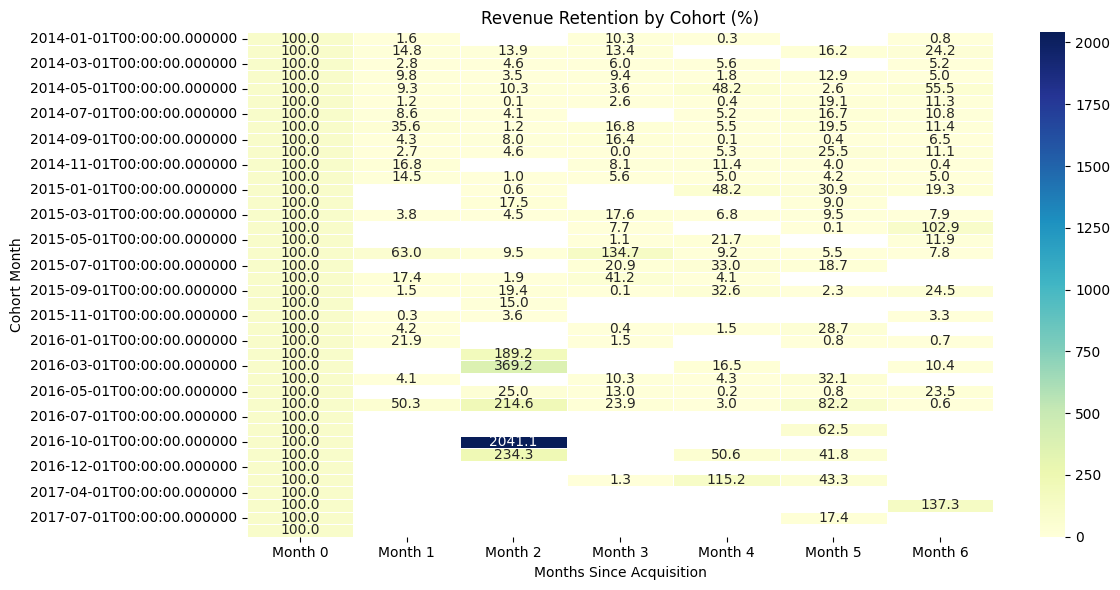

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.heatmap(retention,annot=True,fmt=".1f",cmap="YlGnBu",linewidths=0.5)
plt.title("Revenue Retention by Cohort (%)")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since Acquisition")
plt.tight_layout()
plt.show()

In [27]:
query_shipping = """
SELECT
    ship_mode,
    ROUND(AVG(shipping_time_days)::numeric, 2) AS avg_shipping_time,
    ROUND(AVG(profit)::numeric, 2) AS avg_profit,
    ROUND(SUM(sales)::numeric, 2) AS total_sales,
    COUNT(*) AS total_orders
FROM dt
WHERE shipping_time_days IS NOT NULL
GROUP BY ship_mode
ORDER BY avg_profit DESC;
"""

In [28]:
shipping_df = pd.read_sql(query_shipping, engine)
print(shipping_df)

        ship_mode  avg_shipping_time  avg_profit  total_sales  total_orders
0     First Class               2.18       31.84    351428.42          1538
1    Second Class               3.24       29.54    459193.57          1945
2        Same Day               0.04       29.27    128363.13           543
3  Standard Class               5.01       27.49   1358215.74          5968


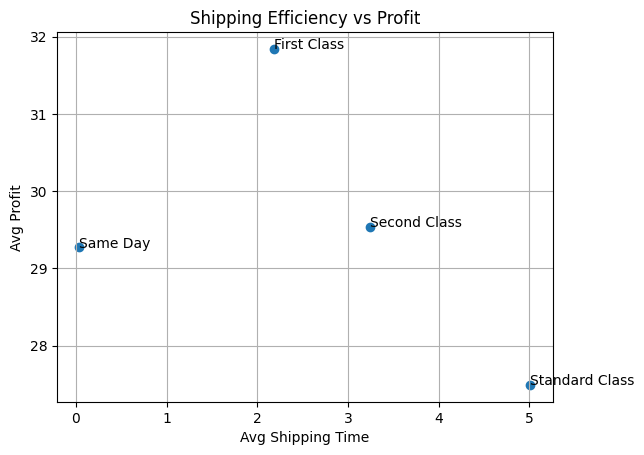

In [29]:
plt.figure()
plt.scatter(shipping_df["avg_shipping_time"], shipping_df["avg_profit"])

for i, txt in enumerate(shipping_df["ship_mode"]):
    plt.annotate(txt, (shipping_df["avg_shipping_time"][i], shipping_df["avg_profit"][i]))

plt.xlabel("Avg Shipping Time")
plt.ylabel("Avg Profit")
plt.title("Shipping Efficiency vs Profit")
plt.grid()
plt.show()

In [34]:
query_risk = """
SELECT CASE WHEN recency <= 30 THEN 'Active'
            WHEN recency <= 90 THEN 'Warm'
            ELSE 'At Risk' END AS customer_status,
COUNT(*) AS customers,ROUND(AVG(monetary)::numeric, 2) AS avg_revenue, ROUND(AVG(frequency)::numeric, 2) AS avg_frequency
FROM du
GROUP BY 1
ORDER BY avg_revenue DESC;
"""

In [35]:
risk_df = pd.read_sql(query_risk, engine)
print(risk_df)

  customer_status  customers  avg_revenue  avg_frequency
0            Warm        239      3261.86           6.67
1          Active        195      3063.05           7.17
2         At Risk        359      2563.57           5.62


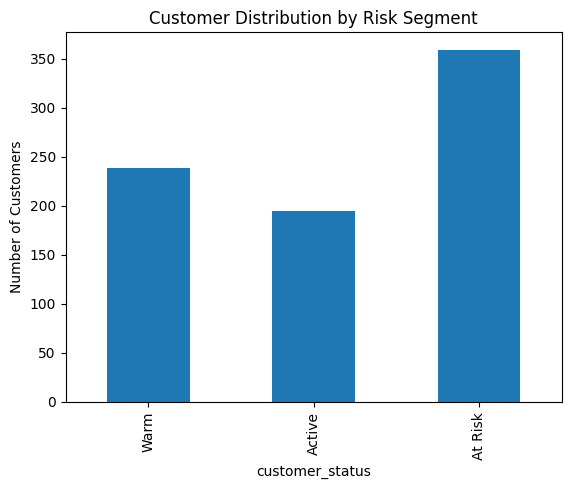

In [36]:
risk_df.set_index("customer_status")["customers"].plot(kind="bar")
plt.title("Customer Distribution by Risk Segment")
plt.ylabel("Number of Customers")
plt.show()

In [37]:
query_revenue = """
WITH monthly_revenue AS (
    SELECT
        DATE_TRUNC('month', order_date) AS month,
        SUM(sales) AS revenue
    FROM dt
    GROUP BY 1
)
SELECT
    month,
    revenue,
    LAG(revenue) OVER (ORDER BY month) AS prev_revenue
FROM monthly_revenue
ORDER BY month;
"""

In [38]:
rev_df = pd.read_sql(query_revenue, engine)

In [39]:
rev_df["growth_%"] = ((rev_df["revenue"] - rev_df["prev_revenue"]) / rev_df["prev_revenue"]) * 100
rev_df = rev_df.round(2)
print(rev_df)

        month    revenue  prev_revenue  growth_%
0  2014-01-01   14236.89           NaN       NaN
1  2014-02-01    4519.89      14236.89    -68.25
2  2014-03-01   55691.01       4519.89   1132.13
3  2014-04-01   28295.34      55691.01    -49.19
4  2014-05-01   23648.29      28295.34    -16.42
5  2014-06-01   34595.13      23648.29     46.29
6  2014-07-01   33946.39      34595.13     -1.88
7  2014-08-01   27909.47      33946.39    -17.78
8  2014-09-01   81777.35      27909.47    193.01
9  2014-10-01   31453.39      81777.35    -61.54
10 2014-11-01   78628.72      31453.39    149.98
11 2014-12-01   69545.62      78628.72    -11.55
12 2015-01-01   18174.08      69545.62    -73.87
13 2015-02-01   11951.41      18174.08    -34.24
14 2015-03-01   38726.25      11951.41    224.03
15 2015-04-01   34195.21      38726.25    -11.70
16 2015-05-01   30131.69      34195.21    -11.88
17 2015-06-01   24797.29      30131.69    -17.70
18 2015-07-01   28765.32      24797.29     16.00
19 2015-08-01   3689

C:\Users\navya\AppData\Local\Temp\ipykernel_22212\1487950792.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  rev_df = rev_df.round(2)


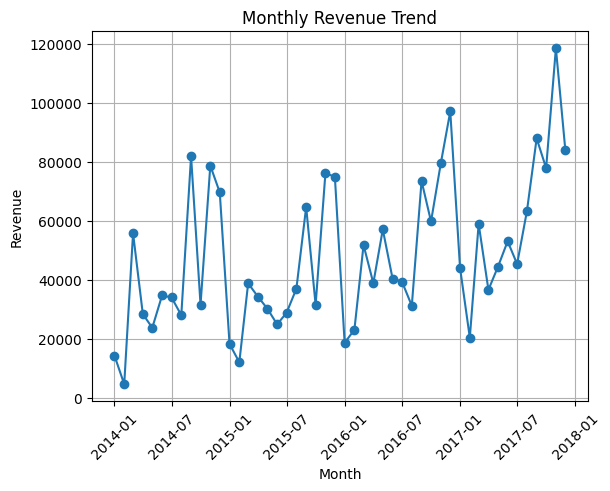

In [40]:
plt.figure()
plt.plot(rev_df["month"], rev_df["revenue"], marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid()
plt.show()